# Multiple Linear Regression

## Import Libraries

In [13]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


## Create Dataset

In [8]:
data = {
    "Canal_Size": [1, 2, 3],
    "Bedrooms": [3, 4, 7],
    "Price": [2, 5, 9]
}

df = pd.DataFrame(data)
print(df)


# Independent variables
X = df[["Canal_Size", "Bedrooms"]]

# Dependent variable
y = df["Price"]


   Canal_Size  Bedrooms  Price
0           1         3      2
1           2         4      5
2           3         7      9


# Create Model

In [9]:
model = LinearRegression()
model.fit(X, y)

# Print coefficients
print("Intercept:", model.intercept_)
print("Coefficient for Canal Size:", model.coef_[0])
print("Coefficient for Bedrooms:", model.coef_[1])

Intercept: -2.000000000000001
Coefficient for Canal Size: 2.5000000000000004
Coefficient for Bedrooms: 0.49999999999999983


## Predict a new house


In [10]:
new_house = [[1.5, 3]]   # Canal Size = 4, Bedrooms = 8
prediction = model.predict(new_house)

print("Predicted Price:", prediction[0])

Predicted Price: 3.249999999999999


/Users/ibtasam/PycharmProjects/machine_learning/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Plot the Regression

/var/folders/lc/qhw86hhj4gxbvpjsxvx19f900000gn/T/ipykernel_98444/1954696351.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


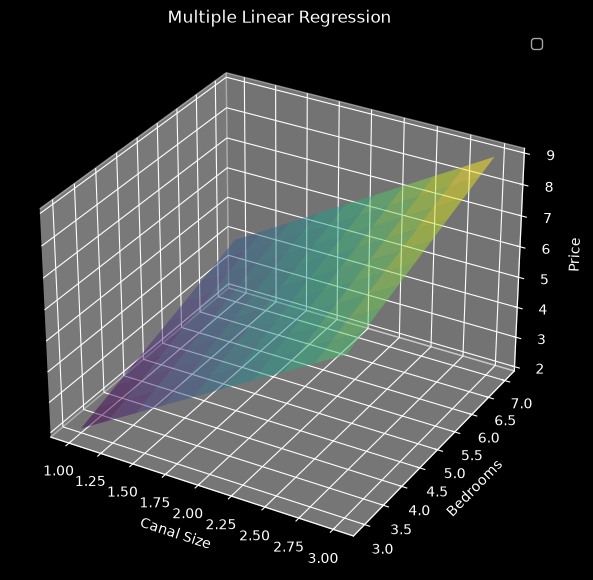

In [15]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
x1 = np.linspace(df["Canal_Size"].min(), df["Canal_Size"].max(), 10)
x2 = np.linspace(df["Bedrooms"].min(), df["Bedrooms"].max(), 10)

X1, X2 = np.meshgrid(x1, x2)

Z = (model.intercept_
     + model.coef_[0] * X1
     + model.coef_[1] * X2)

ax.plot_surface(X1, X2, Z,
                alpha=0.5,
                cmap='viridis')

ax.set_xlabel("Canal Size")
ax.set_ylabel("Bedrooms")
ax.set_zlabel("Price")
ax.set_title("Multiple Linear Regression")

plt.legend()
plt.show()



## Actual vs Predicted

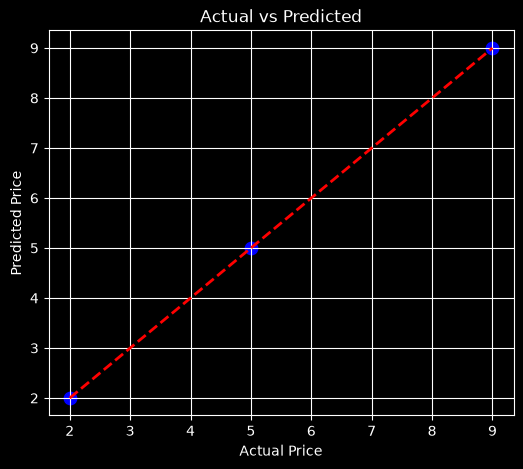

In [20]:
predictions = model.predict(X)


plt.figure(figsize=(6,5))
plt.scatter(y,
            predictions,
            color="blue",
            s=80)

# Perfect prediction line
plt.plot([y.min(), y.max()],
         [y.min(), y.max()],
         color="red",
         linestyle="--",
         linewidth=2)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.grid(True)

plt.show()